<a href="https://colab.research.google.com/github/Zaeemshahid483/DL/blob/main/Tutorial_02/Tutorial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


MLP Structure:
Number of layers: 4
Number of outputs: 3
Activation function: relu
Output activation function: softmax
Number of epochs: 609


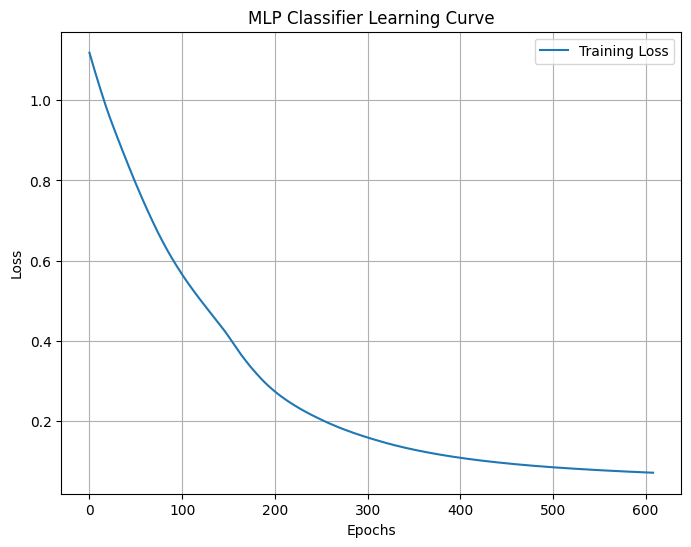


Task 1: Different hidden layers and neurons
Layers: (5,)             Accuracy: 1.00   Epochs: 1000   Final loss: 0.1390
Layers: (10,)            Accuracy: 1.00   Epochs: 1000   Final loss: 0.0947
Layers: (50,)            Accuracy: 1.00   Epochs:  591   Final loss: 0.0735
Layers: (10, 10)         Accuracy: 1.00   Epochs:  609   Final loss: 0.0718
Layers: (50, 50)         Accuracy: 1.00   Epochs:  353   Final loss: 0.0461
Layers: (10, 10, 10)     Accuracy: 1.00   Epochs:  857   Final loss: 0.0318
Layers: (50, 50, 50)     Accuracy: 0.98   Epochs:  397   Final loss: 0.0047
Layers: (100, 100, 100)  Accuracy: 1.00   Epochs:  239   Final loss: 0.0031


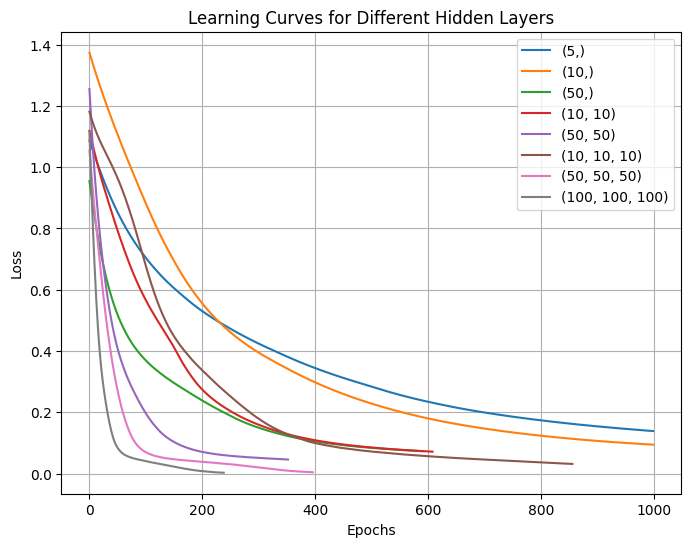


Task 2: Different learning rates
Learning rate: 0.0001  Accuracy: 0.73   Epochs: 1000   Final loss: 0.5507
Learning rate: 0.001   Accuracy: 1.00   Epochs:  609   Final loss: 0.0718
Learning rate: 0.01    Accuracy: 1.00   Epochs:  157   Final loss: 0.0494
Learning rate: 0.1     Accuracy: 0.96   Epochs:  159   Final loss: 0.0011
Learning rate: 0.5     Accuracy: 1.00   Epochs:   73   Final loss: 0.0542


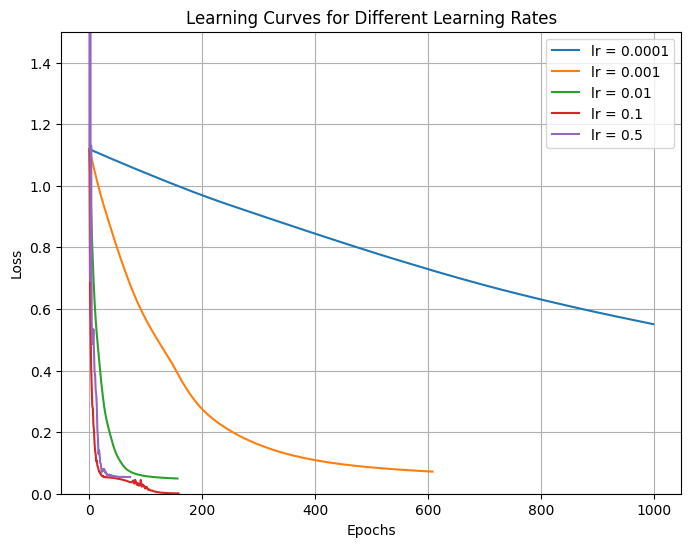

In [2]:
import warnings
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Loading and splitting the dataset
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the MLP
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42, learning_rate_init=0.001)
mlp.fit(X_train_scaled, y_train)

# Evaluation
y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print("Classification Report:\n", classification_report(y_test, y_pred))

# MLP structure
print("\nMLP Structure:")
print(f"Number of layers: {mlp.n_layers_}")
print(f"Number of outputs: {mlp.n_outputs_}")
print(f"Activation function: {mlp.activation}")
print(f"Output activation function: {mlp.out_activation_}")
print(f"Number of epochs: {mlp.n_iter_}")

# Learning curve
plt.figure(figsize=(8, 6))
plt.plot(mlp.loss_curve_, label='Training Loss')
plt.title('MLP Classifier Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


# Task 1: different hidden layers and neurons
print("\nTask 1: Different hidden layers and neurons")
configs = [(5,), (10,), (50,), (10, 10), (50, 50), (10, 10, 10), (50, 50, 50), (100, 100, 100)]

plt.figure(figsize=(8, 6))
for config in configs:
    model = MLPClassifier(hidden_layer_sizes=config, max_iter=1000, random_state=42, learning_rate_init=0.001)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"Layers: {str(config):16} Accuracy: {acc:.2f}   Epochs: {model.n_iter_:4}   Final loss: {model.loss_:.4f}")
    plt.plot(model.loss_curve_, label=str(config))

plt.title('Learning Curves for Different Hidden Layers')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


# Task 2: different learning rates
print("\nTask 2: Different learning rates")
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]

plt.figure(figsize=(8, 6))
for lr in learning_rates:
    model = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42, learning_rate_init=lr)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"Learning rate: {lr:<7} Accuracy: {acc:.2f}   Epochs: {model.n_iter_:4}   Final loss: {model.loss_:.4f}")
    plt.plot(model.loss_curve_, label=f'lr = {lr}')

plt.title('Learning Curves for Different Learning Rates')
plt.ylim(0, 1.5)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()